# System Identification and Adaptive Control

## 1. Motivation

So far, our control methods assumed that the system dynamics were known:

$$
x_{k+1} = f(x_k, u_k).
$$

For example, MPC and iLQR used this dynamics model to predict future states.

In practice, however, the true system may contain unknown parameters or modeling errors.

Examples include:

- unknown vehicle mass,
- uncertain tire or friction parameters,
- actuator gain errors,
- changing payload,
- environmental disturbances.

This raises a new question:

> What if the controller does not know the true dynamics?

Learning can then be used to estimate the system or adapt the controller.

## 2. Learning Settings

There are three useful ways to think about learning for control.

### 1. Offline system identification

Data is collected before deployment and used to estimate a model:

$$
\mathcal D=
\{x_k,u_k,x_{k+1}\}.
$$

From the data, we estimate:

$$
\hat f(x,u)
\approx
f(x,u).
$$

The learned model is then used by the controller.

### 2. Adaptive control

The system operates continuously while model or controller parameters are
updated online.

The controller therefore adapts as new observations become available.

### 3. Reinforcement learning

The agent interacts with the environment over multiple episodes and improves
its policy from experience.

This notebook focuses on the first two settings.

## 3. Unknown Dynamics Example

Consider a 1D vehicle with state:

$$
x=
\begin{bmatrix}
p\\
v
\end{bmatrix}
$$

and control:

$$
u=a_{\text{cmd}}.
$$

The true dynamics are:

$$
p_{k+1}=
p_k+\Delta t\,v_k
$$

$$
v_{k+1}=
v_k+\Delta t\,\theta u_k.
$$

The parameter $\theta$ describes actuator effectiveness and is assumed to be
unknown to the controller.

Our goal is to estimate $\theta$ from observed state transitions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
DT = 0.1

THETA_TRUE = 0.7

In [3]:
def true_dynamics(x, u):

    p, v = x

    p_next = (
        p
        + DT * v
    )

    v_next = (
        v
        + DT * THETA_TRUE * u
    )

    return np.array([
        p_next,
        v_next
    ])

## 4. Collecting Data

To identify the unknown parameter $\theta$, we apply different control inputs
to the system and observe the resulting state transitions.

For each timestep we collect:

$$
(x_k,\;u_k,\;x_{k+1}).
$$

From the velocity dynamics,

$$
v_{k+1}=
v_k+\Delta t\,\theta u_k,
$$

we obtain:

$$
v_{k+1}-v_k=
\Delta t\,\theta u_k.
$$

Therefore, the observed velocity change contains information about the
unknown parameter $\theta$.

An important requirement is **excitation**: if we never apply meaningful
control inputs, there is little information available to identify the
dynamics.

In [4]:
np.random.seed(0)

N_DATA = 100

x = np.array([
    0.0,   # position
    0.0    # velocity
])

data = []

for k in range(N_DATA):

    # Excite the system using different controls
    u = np.random.uniform(
        -2.0,
        2.0
    )

    x_next = true_dynamics(
        x,
        u
    )

    data.append({
        "x": x.copy(),
        "u": u,
        "x_next": x_next.copy()
    })

    x = x_next

## 5. Parameter Estimation using Least Squares

The velocity dynamics are:

$$
v_{k+1}-v_k=
\Delta t\,\theta u_k.
$$

Define:

$$
y_k = v_{k+1}-v_k
$$

and

$$
\phi_k = \Delta t\,u_k.
$$

Then:

$$
y_k = \phi_k\theta.
$$

Collecting many observations gives the linear regression problem:

$$
Y=\Phi\theta.
$$

The least-squares estimate is:

$$
\hat{\theta}=
(\Phi^T\Phi)^{-1}\Phi^TY.
$$

Thus, system identification can be viewed as estimating the parameters of a
dynamics model from observed state transitions.

In [5]:
Y = []
Phi = []

for sample in data:

    x = sample["x"]
    u = sample["u"]
    x_next = sample["x_next"]

    v = x[1]
    v_next = x_next[1]

    y = v_next - v
    phi = DT * u

    Y.append(y)
    Phi.append([phi])

Y = np.array(Y)
Phi = np.array(Phi)

In [6]:
print("Phi shape:", Phi.shape)
print("Y shape:", Y.shape)

Phi shape: (100, 1)
Y shape: (100,)


In [7]:
theta_hat = np.linalg.solve(
    Phi.T @ Phi,
    Phi.T @ Y
)

print("True theta:     ", THETA_TRUE)
print("Estimated theta:", theta_hat[0])

True theta:      0.7
Estimated theta: 0.7


## 6. System Identification with Measurement Noise

So far, the state transitions were measured perfectly.

In a real system, measurements contain noise due to sensors, disturbances,
unmodeled dynamics, and other sources of uncertainty.

We can represent the measured velocity as:

$$
v_k^{meas} = v_k + \epsilon_k
$$

where:

$$
\epsilon_k \sim \mathcal{N}(0,\sigma^2).
$$

The identification problem therefore becomes:

$$
Y = \Phi\theta + \epsilon.
$$

A single transition may give a poor estimate of $\theta$.

By collecting many transitions and solving a least-squares problem, we can
find the parameter that best explains all observations.

In [9]:
np.random.seed(1)

N_DATA = 100
NOISE_STD = 0.02

x = np.array([
    0.0,
    0.0
])

data_noisy = []

for k in range(N_DATA):

    u = np.random.uniform(
        -2.0,
        2.0
    )

    # True physical transition
    x_next = true_dynamics(x, u)

    # Noisy velocity measurements
    v_measured = (
        x[1]
        + np.random.normal(0.0, NOISE_STD)
    )

    v_next_measured = (
        x_next[1]
        + np.random.normal(0.0, NOISE_STD)
    )

    data_noisy.append({
        "v": v_measured,
        "u": u,
        "v_next": v_next_measured
    })

    x = x_next

In [10]:
Y = []
Phi = []

for sample in data_noisy:

    y = (
        sample["v_next"]
        - sample["v"]
    )

    phi = (
        DT
        * sample["u"]
    )

    Y.append(y)
    Phi.append([phi])

Y = np.array(Y)
Phi = np.array(Phi)

In [11]:
theta_hat = np.linalg.solve(
    Phi.T @ Phi,
    Phi.T @ Y
)

print("True theta:     ", THETA_TRUE)
print("Estimated theta:", theta_hat[0])

True theta:      0.7
Estimated theta: 0.6771790222817902


## 7. Why Multiple Measurements Help

In [12]:
theta_individual = []

for sample in data_noisy:

    u = sample["u"]

    # Avoid division by controls very close to zero
    if abs(u) > 0.2:

        theta_k = (
            sample["v_next"]
            - sample["v"]
        ) / (DT * u)

        theta_individual.append(theta_k)

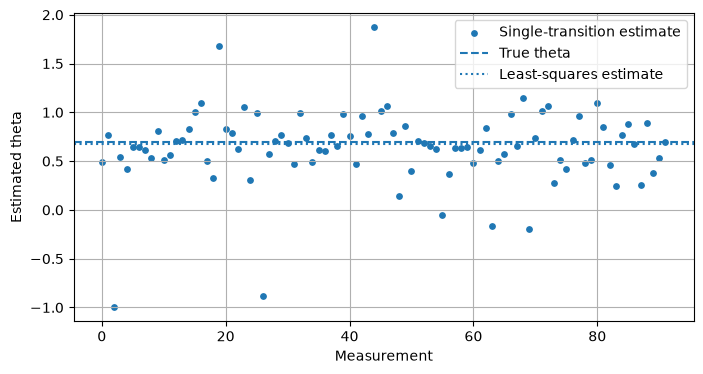

In [15]:
plt.figure(figsize=(8, 4))

plt.scatter(
    range(len(theta_individual)),
    theta_individual,
    s=15,
    label="Single-transition estimate"
)

plt.axhline(
    THETA_TRUE,
    linestyle="--",
    label="True theta"
)

plt.axhline(
    theta_hat[0],
    linestyle=":",
    label="Least-squares estimate"
)

plt.xlabel("Measurement")
plt.ylabel("Estimated theta")
plt.legend()
plt.grid()

plt.show()

## 8. From System Identification to Adaptive Control

Offline system identification assumes that we first collect data, estimate
the model, and then design the controller.

Adaptive control instead updates the model or controller while the system
is operating.

A model-identification adaptive controller can be viewed as:

$$
\text{Plant}
\rightarrow
\text{Data}
\rightarrow
\text{Parameter Estimator}
\rightarrow
\hat{\theta}_k
\rightarrow
\text{Controller}
$$

The controller therefore changes as our estimate of the system improves.

This creates a feedback loop between:

1. acting,
2. observing,
3. estimating,
4. controlling.

## 9. Recursive Least Squares

Batch least squares estimates the model parameters using an entire dataset:

$$
\hat{\theta}=
(\Phi^T\Phi)^{-1}\Phi^T Y.
$$

For adaptive control, however, data arrives sequentially while the system is
operating.

Instead of solving the complete least-squares problem after every new
measurement, Recursive Least Squares (RLS) updates the parameter estimate
incrementally:

$$
\hat{\theta}_k
\rightarrow
\hat{\theta}_{k+1}.
$$

For a measurement model

$$
y_k = \phi_k^T\theta + \epsilon_k,
$$

RLS performs three main operations:

1. predict the new measurement,
2. compute the prediction error,
3. correct the parameter estimate.

## 10. RLS Update

Given the current parameter estimate $\hat{\theta}_k$, first predict the
measurement:

$$
\hat{y}_k=
\phi_k^T\hat{\theta}_k.
$$

The prediction error is:

$$
e_k=
y_k-\phi_k^T\hat{\theta}_k.
$$

RLS then computes a gain:

$$
K_k=
\frac{P_k\phi_k}
{1+\phi_k^T P_k\phi_k}.
$$

The parameter estimate is corrected using:

$$
\hat{\theta}_{k+1}=
\hat{\theta}_k
+
K_k e_k.
$$

Finally:

$$
P_{k+1}=
P_k-
\frac{
P_k\phi_k\phi_k^T P_k
}{
1+\phi_k^T P_k\phi_k
}.
$$

The structure is therefore:

$$
\boxed{
\text{predict}
\rightarrow
\text{measure error}
\rightarrow
\text{correct model}
}
$$

## 11. Implement RLS. 

In [16]:
theta_hat = np.array([1.5])

# Large initial uncertainty
P = np.array([
    [100.0]
])

theta_history = [
    theta_hat[0]
]

In [17]:
np.random.seed(2)

N_STEPS = 100
NOISE_STD = 0.02

x = np.array([
    0.0,
    0.0
])

for k in range(N_STEPS):

    # Excitation input
    u = np.random.uniform(
        -2.0,
        2.0
    )

    # True system
    x_next = true_dynamics(
        x,
        u
    )

    # Noisy measurements
    v_measured = (
        x[1]
        + np.random.normal(0.0, NOISE_STD)
    )

    v_next_measured = (
        x_next[1]
        + np.random.normal(0.0, NOISE_STD)
    )

    # Regression quantities
    y = np.array([
        v_next_measured
        - v_measured
    ])

    phi = np.array([
        [DT * u]
    ])

    # Prediction
    y_hat = phi.T @ theta_hat

    # Prediction error
    error = y - y_hat

    # RLS gain
    K = (
        P @ phi
        / (
            1.0
            + phi.T @ P @ phi
        )
    )

    # Parameter update
    theta_hat = (
        theta_hat
        + K.flatten() * error
    )

    # Covariance update
    P = (
        P
        - K @ phi.T @ P
    )

    theta_history.append(
        theta_hat[0]
    )

    x = x_next

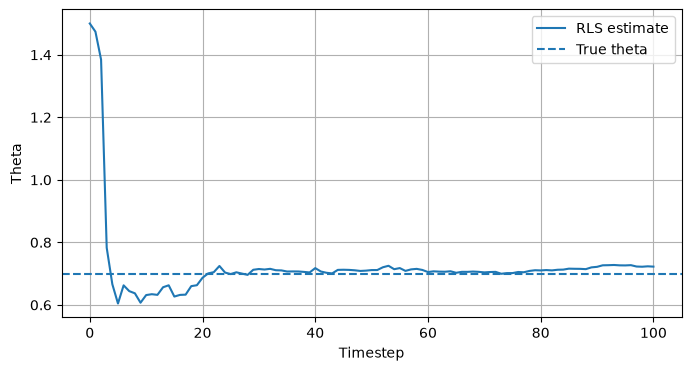

In [18]:
plt.figure(figsize=(8, 4))

plt.plot(
    theta_history,
    label="RLS estimate"
)

plt.axhline(
    THETA_TRUE,
    linestyle="--",
    label="True theta"
)

plt.xlabel("Timestep")
plt.ylabel("Theta")
plt.legend()
plt.grid()

plt.show()

## 12. Adaptive Velocity Control

We now use the estimated model inside the controller.

The goal is to track a desired velocity:

$$
v_{\text{ref}}.
$$

Define the velocity tracking error:

$$
e_v=
v_{\text{ref}}-v_k.
$$

A proportional controller requests the desired acceleration:

$$
a_{\text{desired}}=
K_p e_v.
$$

Our estimated dynamics are:

$$
a
\approx
\hat{\theta}_k u_k.
$$

Therefore, the control input is chosen as:

$$
u_k=
\frac{
K_p(v_{\text{ref}}-v_k)
}{
\hat{\theta}_k
}.
$$

As the model estimate $\hat{\theta}_k$ improves, the controller automatically
adjusts its control input.

## 13. Implement the Adaptive Controller

In [20]:
np.random.seed(3)

N_STEPS = 150
V_REF = 10.0
KP = 1.0

NOISE_STD = 0.02

# Initial state
x = np.array([
    0.0,
    0.0
])

# Deliberately incorrect model
theta_hat = np.array([1.5])

# Initial estimator uncertainty
P = np.array([
    [100.0]
])

velocity_history = []
control_history = []
theta_history = []

In [21]:
for k in range(N_STEPS):

    v = x[1]

    # --------------------------------
    # Controller
    # --------------------------------

    velocity_error = (
        V_REF - v
    )

    u = (
        KP * velocity_error
        / theta_hat[0]
    )

    # Limit actuator command
    u = np.clip(
        u,
        -3.0,
        3.0
    )

    # --------------------------------
    # True physical system
    # --------------------------------

    x_next = true_dynamics(
        x,
        u
    )

    # --------------------------------
    # Measurements
    # --------------------------------

    v_measured = (
        x[1]
        + np.random.normal(
            0.0,
            NOISE_STD
        )
    )

    v_next_measured = (
        x_next[1]
        + np.random.normal(
            0.0,
            NOISE_STD
        )
    )

    # --------------------------------
    # RLS estimator
    # --------------------------------

    y = np.array([
        v_next_measured
        - v_measured
    ])

    phi = np.array([
        [DT * u]
    ])

    y_hat = (
        phi.T
        @ theta_hat
    )

    prediction_error = (
        y - y_hat
    )

    K = (
        P @ phi
        / (
            1.0
            + phi.T @ P @ phi
        )
    )

    theta_hat = (
        theta_hat
        + K.flatten()
        * prediction_error
    )

    P = (
        P
        - K @ phi.T @ P
    )

    # --------------------------------
    # Store results
    # --------------------------------

    velocity_history.append(
        x[1]
    )

    control_history.append(
        u
    )

    theta_history.append(
        theta_hat[0]
    )

    x = x_next

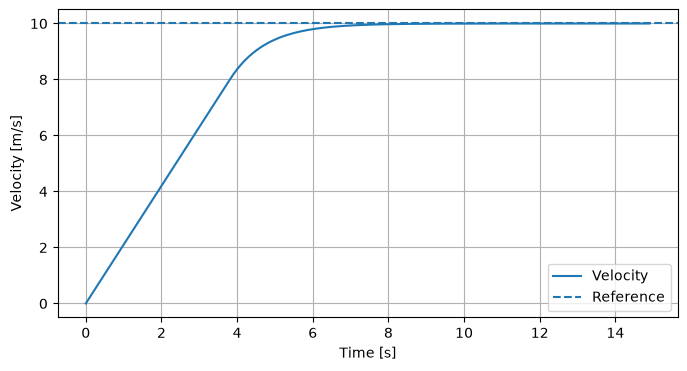

In [22]:
time = (
    np.arange(N_STEPS)
    * DT
)

plt.figure(figsize=(8, 4))

plt.plot(
    time,
    velocity_history,
    label="Velocity"
)

plt.axhline(
    V_REF,
    linestyle="--",
    label="Reference"
)

plt.xlabel("Time [s]")
plt.ylabel("Velocity [m/s]")
plt.legend()
plt.grid()

plt.show()

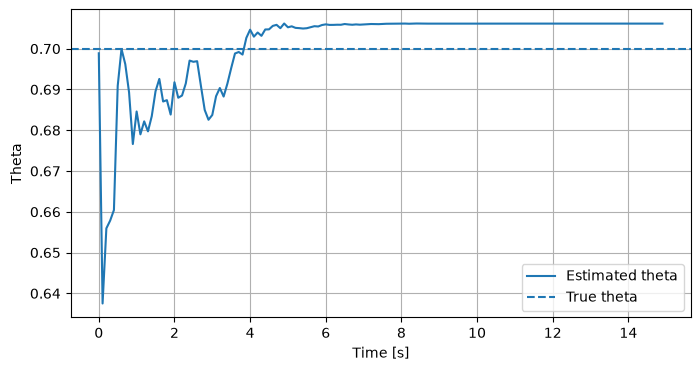

In [23]:
plt.figure(figsize=(8, 4))

plt.plot(
    time,
    theta_history,
    label="Estimated theta"
)

plt.axhline(
    THETA_TRUE,
    linestyle="--",
    label="True theta"
)

plt.xlabel("Time [s]")
plt.ylabel("Theta")
plt.legend()
plt.grid()

plt.show()

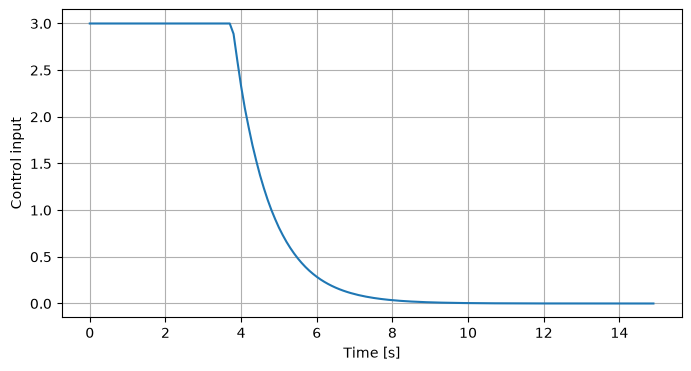

In [24]:
plt.figure(figsize=(8, 4))

plt.plot(
    time,
    control_history
)

plt.xlabel("Time [s]")
plt.ylabel("Control input")
plt.grid()

plt.show()

## 14. Excitation and Identifiability

Learning a dynamics model requires informative data.

For our system:

$$
v_{k+1}-v_k=
\Delta t\,u_k\theta,
$$

the unknown parameter $\theta$ affects the observation through the control
input $u_k$.

If:

$$
u_k \approx 0,
$$

then:

$$
v_{k+1}-v_k \approx 0,
$$

almost independently of $\theta$.

Therefore, the estimator receives little information about the unknown
parameter.

This motivates the idea of **persistent excitation**: the system inputs must
be sufficiently rich for the unknown dynamics parameters to be identifiable.

## 15. Control vs Learning

An interesting conflict appears once we combine system identification with control.

The controller's objective is to regulate the system, while the estimator's objective is to learn the unknown dynamics.

For our adaptive controller, the control law is:

$$
u_k=
\frac{K_p(v_{\text{ref}}-v_k)}
{\hat{\theta}_k}.
$$

As the vehicle approaches the desired velocity,

$$
v_k \rightarrow v_{\text{ref}},
$$

the tracking error becomes small,

$$
e_v \rightarrow 0,
$$

and consequently,

$$
u_k \rightarrow 0.
$$

This is excellent for **control**, because the vehicle has reached its desired operating point.

However, the estimator learns from

$$
y_k=\phi_k\theta+\epsilon_k,
$$

where

$$
\phi_k=\Delta t\,u_k.
$$

When the control input becomes very small,

$$
u_k \approx 0,
$$

we obtain

$$
\phi_k \approx 0,
$$

meaning that new observations contain very little information about the unknown parameter.

The controller therefore faces a trade-off:

$$
\boxed{
\text{good regulation}
\rightarrow
\text{small control activity}
\rightarrow
\text{less informative data}
}
$$

One possible solution is to deliberately add small exploratory inputs:

$$
u_k=
u_k^{\text{control}}
+
u_k^{\text{exploration}}.
$$

The exploration term excites the system, allowing the estimator to continue improving the model.

This introduces an important idea that will reappear throughout reinforcement learning:

$$
\boxed{
\text{Exploration}
\leftrightarrow
\text{Exploitation}
}
$$

- **Exploitation:** use the current model to achieve the control objective.
- **Exploration:** gather information that improves future decisions.

Although adaptive control and reinforcement learning solve different problems, this tension between immediate performance and information gathering is a recurring theme in intelligent decision-making systems.

## 16. Two Adaptive-Control Architectures

Two important adaptive-control approaches are:

### Model Identification Adaptive Control (MIAC)

MIAC explicitly estimates the system model:

$$
\text{data}
\rightarrow
\hat{\theta}
\rightarrow
\hat f(x,u)
\rightarrow
\text{controller}.
$$

The model parameters are updated based on how well the estimated model fits
the observed system behavior.

This is the approach used in our RLS example.

### Model Reference Adaptive Control (MRAC)

MRAC instead specifies a desired reference model describing how the system
should behave.

The controller parameters are adapted so that the actual system follows the
reference-model behavior.

The adaptation is therefore driven primarily by tracking error rather than
model-identification error.

## 17. MRAC Intuition

**Model Reference Adaptive Control (MRAC)** takes a different approach from
model-identification adaptive control.

Instead of explicitly estimating the unknown dynamics of the plant, MRAC
defines a **reference model** describing how we would like the system to behave.

Suppose the desired velocity command is:

$$
r_k = 10 \text{ m/s}.
$$

A reference model generates the desired dynamic response:

$$
v_{m,k+1}=
f_m(v_{m,k}, r_k),
$$

where $v_m$ represents the desired system behavior.

For example, rather than reaching the target velocity instantaneously, the
reference model may specify a smooth response:

$$
0
\rightarrow
2
\rightarrow
4
\rightarrow
6
\rightarrow
8
\rightarrow
10.
$$

The actual plant produces its own response:

$$
v_k.
$$

MRAC compares the actual system with the reference model using the tracking
error:

$$
e_k=
v_k-v_{m,k}.
$$

The controller parameters are then adapted so that this error decreases:

$$
e_k \rightarrow 0.
$$

Conceptually, the architecture is:

$$
r_k
\rightarrow
\text{Reference Model}
\rightarrow
v_{m,k}
$$

and

$$
r_k
\rightarrow
\text{Adaptive Controller}
\rightarrow
\text{Plant}
\rightarrow
v_k.
$$

The difference between the two responses,

$$
e_k=v_k-v_{m,k},
$$

is used to update the controller parameters.

Therefore, the main objective of MRAC is:

$$
\boxed{
\text{adapt the controller so that the plant follows the desired reference model}
}
$$

This differs from MIAC, where the adaptation is driven by the error between
the predicted and observed system dynamics.

In short:

$$
\boxed{
\text{MIAC: learn the plant model}
}
$$

$$
\boxed{
\text{MRAC: make the plant follow a desired model}
}
$$

|                                | MIAC                     | MRAC                  |
| ------------------------------ | ------------------------ | --------------------- |
| Main thing adapted             | Model estimate           | Controller parameters |
| Main error                     | Model/data-fitting error | Tracking error        |
| Explicit system identification | Yes                      | Not necessarily       |
| Reference model                | Not required             | Central               |
| Our RLS example                | ✓                        |                       |


## 18. Certainty-Equivalent vs Cautious Control

Our adaptive controller uses the current point estimate:

$$
\hat{\theta}_k
$$

as if it were the true parameter.

The controller therefore solves the control problem using:

$$
f(x,u;\hat{\theta}_k).
$$

This is called **certainty-equivalent control**.

It ignores uncertainty about the parameter estimate.

A cautious controller instead reasons about the uncertainty in the model:

$$
\theta \sim p(\theta \mid \mathcal D).
$$

The controller can then choose actions that remain safe or effective across
plausible model parameters.

Thus:

$$
\text{certainty equivalent}
\rightarrow
\text{use best estimate}
$$

while:

$$
\text{cautious control}
\rightarrow
\text{account for uncertainty in estimate}.
$$

## 19. Cautious Control

A point estimate does not describe how confident we are in the estimated
model.

For example, consider two situations:

### Case 1: Little data

$$
\hat{\theta}=0.8
$$

but the estimate is highly uncertain.

### Case 2: Large amount of informative data

$$
\hat{\theta}=0.8
$$

and the estimate is highly reliable.

A certainty-equivalent controller treats both cases identically.

A **cautious controller** instead accounts for uncertainty in the model
parameters.

Conceptually, instead of considering only:

$$
\hat{\theta},
$$

we consider a range or distribution of plausible models:

$$
\theta \sim p(\theta \mid \mathcal D).
$$

The controller can then choose actions that perform reasonably across the
plausible dynamics.

Therefore:

$$
\boxed{
\text{Certainty Equivalent}
\rightarrow
\text{control using the best estimate}
}
$$

while:

$$
\boxed{
\text{Cautious Control}
\rightarrow
\text{control while accounting for model uncertainty}
}
$$

## 20. Summary

In previous notebooks, we assumed that the system dynamics were known:

$$
x_{k+1}=f(x_k,u_k).
$$

This notebook introduced the case where the dynamics contain unknown
parameters:

$$
x_{k+1}=f(x_k,u_k;\theta).
$$

### System Identification

We first collected transition data:

$$
\mathcal D=
\{x_k,u_k,x_{k+1}\},
$$

and estimated the unknown dynamics parameter using least squares:

$$
\hat{\theta}=
\arg\min_\theta
\|Y-\Phi\theta\|^2.
$$

This gave the normal equations:

$$
\Phi^T\Phi\hat{\theta}=
\Phi^TY.
$$

### Online Identification

Recursive Least Squares (RLS) allowed us to update the model sequentially:

$$
\hat{\theta}_k
\rightarrow
\hat{\theta}_{k+1}.
$$

The estimator followed the general structure:

$$
\boxed{
\text{predict}
\rightarrow
\text{measure prediction error}
\rightarrow
\text{update model}
}
$$

### Adaptive Control

We then used the estimated dynamics inside the controller:

$$
\hat{\theta}_k
\rightarrow
\text{Controller}
\rightarrow
u_k
\rightarrow
\text{Plant}
\rightarrow
\text{Data}
\rightarrow
\hat{\theta}_{k+1}.
$$

This demonstrated the basic idea behind **Model Identification Adaptive
Control (MIAC)**.

We also contrasted it with **Model Reference Adaptive Control (MRAC)**:

$$
\boxed{
\text{MIAC}
\rightarrow
\text{adapt using model/data-fitting error}
}
$$

$$
\boxed{
\text{MRAC}
\rightarrow
\text{adapt using reference-model tracking error}
}
$$

### Control and Learning

The actions chosen by a controller determine not only how the system behaves,
but also what information is collected.

This creates a trade-off between:

$$
\boxed{
\text{control performance}
\leftrightarrow
\text{information gathering}
}
$$

and introduces the intuition behind exploration and exploitation.

Finally, we distinguished between:

$$
\text{certainty-equivalent control}
$$

which treats the current model estimate as correct, and:

$$
\text{cautious control}
$$

which explicitly considers uncertainty in the estimated model.

## 21. From Adaptive Control to Learning-Based Control

So far, the controller itself has largely been designed using our knowledge
of the system and control objective.

For example, in the adaptive velocity controller we explicitly designed:

$$
u_k=
\frac{
K_p(v_{\text{ref}}-v_k)
}{
\hat{\theta}_k
}.
$$

Learning was used to estimate the unknown dynamics parameter:

$$
\theta
\rightarrow
\hat{\theta}_k.
$$

Therefore, the overall structure was:

$$
\boxed{
\text{Learn Model}
\rightarrow
\text{Use Designed Controller}
}
$$

This raises a natural question:

> Instead of designing the control policy ourselves, can we learn the policy
> directly from data?

Suppose an expert controller already exists:

$$
u_k^{\text{expert}}=
\pi_{\text{expert}}(x_k).
$$

By observing the expert, we can construct a dataset:

$$
\mathcal D=
\{
(x_k,u_k^{\text{expert}})
\}.
$$

We can then train a parameterized policy:

$$
\pi_\theta(x_k)
\approx
u_k^{\text{expert}}.
$$

This leads to **Imitation Learning**.

The learning target therefore changes:

### System Identification

$$
(x_k,u_k,x_{k+1})
\rightarrow
\boxed{\hat f(x,u)}
$$

We learn how the system behaves.

### Imitation Learning

$$
(x_k,u_k^{\text{expert}})
\rightarrow
\boxed{\pi_\theta(u|x)}
$$

We learn how an expert behaves.

### Reinforcement Learning

Instead of requiring expert actions, reinforcement learning uses interaction
and reward:

$$
(x_k,u_k,r_k,x_{k+1})
\rightarrow
\boxed{\text{improved decision-making policy}}
$$

This gives the progression:

$$
\boxed{
\text{System Identification}
\rightarrow
\text{Imitation Learning}
\rightarrow
\text{Reinforcement Learning}
}
$$